In [ ]:
!pip install ultralytics opencv-python pandas scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.2 MB/s eta 0:00:00


In [ ]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

token = "KGAT_382cbe54d61b51d36796942f9d4d2da6"

with open("/root/.kaggle/access_token", "w") as f:
    f.write(token)

os.chmod("/root/.kaggle/access_token", 0o600)

In [ ]:
!kaggle datasets list -s "hard hat detection"

ref                                                         title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
muhammetzahitaydn/hardhat-vest-dataset-v3                   HardHat-Vest Dataset                              4517318395  2023-05-01 14:29:25.490000           6247         56                1  
adilshamim8/safety-helmet-detection-for-construction-sites  Safety Helmet Detection for Construction Sites    1119097323  2025-07-05 10:37:27.317000            585          6                1  
andrewmvd/hard-hat-detection                                Safety Helmet Detection                           1314241385  2020-08-11 07:40:12.883000          30880        439            0.875  
mustafatayyipbayram/ppe-detect

In [ ]:
!mkdir -p /content/datasets/raw
!kaggle datasets download -d andrewmvd/hard-hat-detection -p /content/datasets/raw

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection
License(s): CC0-1.0
100% 1.22G/1.22G [01:02<00:00, 21.1MB/s]



In [ ]:
!unzip /content/datasets/raw/hard-hat-detection.zip -d /content/datasets/raw/hard_hat_detection

Streaming output truncated to the last 5000 lines.
  inflating: /content/datasets/raw/hard_hat_detection/images/hard_hat_workers0.png  
  inflating: /content/datasets/raw/hard_hat_detection/images/hard_hat_workers1.png  
  inflating: /content/datasets/raw/hard_hat_detection/images/hard_hat_workers10.png  
  inflating: /content/datasets/raw/hard_hat_detection/images/hard_hat_workers100.png  
  inflating: /content/datasets/raw/hard_hat_detection/images/hard_hat_workers1000.png  
  inflating: /content/datasets/raw/hard_hat_detection/images/hard_hat_workers1001.png  
  inflating: /content/datasets/raw/hard_hat_detection/images/hard_hat_workers1002.png  
  inflating: /content/datasets/raw/hard_hat_detection/images/hard_hat_workers1003.png  
  inflating: /content/datasets/raw/hard_hat_detection/images/hard_hat_workers1004.png  
  inflating: /content/datasets/raw/hard_hat_detection/images/hard_hat_workers1005.png  
  inflating: /content/datasets/raw/hard_hat_detection/images/hard_hat_workers1

In [ ]:
import os

root = "/content/datasets/raw/hard_hat_detection"

for path, dirs, files in os.walk(root):
    print("PATH:", path)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("-" * 50)

PATH: /content/datasets/raw/hard_hat_detection
DIRS: ['images', 'annotations']
FILES: []
--------------------------------------------------
PATH: /content/datasets/raw/hard_hat_detection/images
DIRS: []
FILES: ['hard_hat_workers2211.png', 'hard_hat_workers2253.png', 'hard_hat_workers1881.png', 'hard_hat_workers317.png', 'hard_hat_workers479.png']
--------------------------------------------------
PATH: /content/datasets/raw/hard_hat_detection/annotations
DIRS: []
FILES: ['hard_hat_workers1363.xml', 'hard_hat_workers1267.xml', 'hard_hat_workers267.xml', 'hard_hat_workers3381.xml', 'hard_hat_workers2204.xml']
--------------------------------------------------


In [ ]:
import os
import xml.etree.ElementTree as ET
from collections import Counter

annotations_dir = "/content/datasets/raw/hard_hat_detection/annotations"

class_counter = Counter()

for file_name in os.listdir(annotations_dir):
    if file_name.endswith(".xml"):
        xml_path = os.path.join(annotations_dir, file_name)
        tree = ET.parse(xml_path)
        root = tree.getroot()

        for obj in root.findall("object"):
            class_name = obj.find("name").text
            class_counter[class_name] += 1

print(class_counter)

Counter({'helmet': 18966, 'head': 5785, 'person': 751})


/content/datasets/raw/hard_hat_detection/images/hard_hat_workers0.png


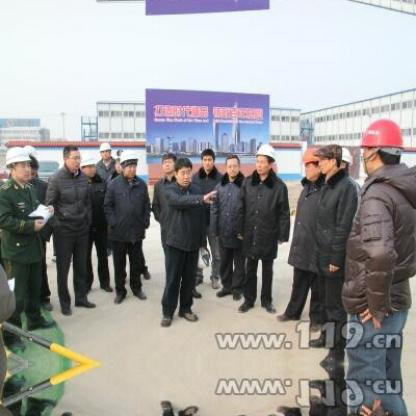

/content/datasets/raw/hard_hat_detection/images/hard_hat_workers1.png


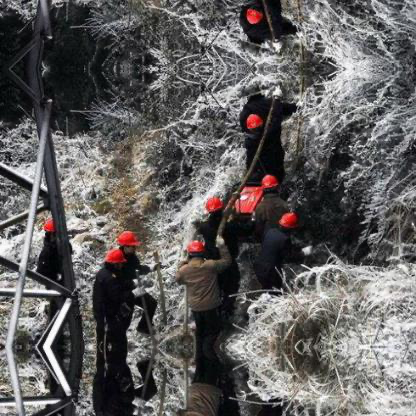

/content/datasets/raw/hard_hat_detection/images/hard_hat_workers10.png


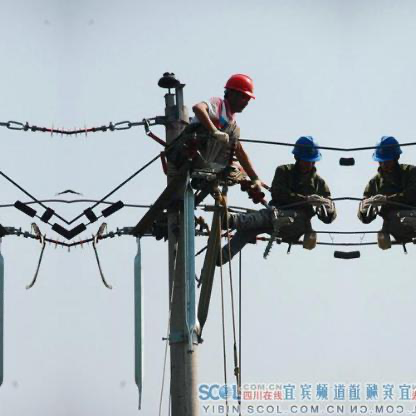

/content/datasets/raw/hard_hat_detection/images/hard_hat_workers100.png


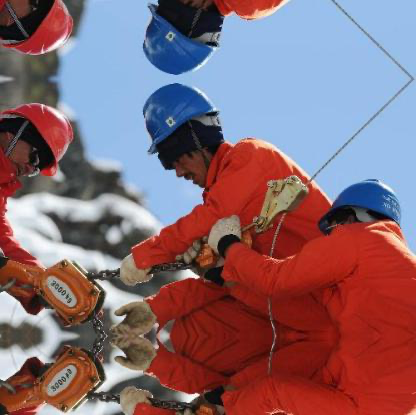

/content/datasets/raw/hard_hat_detection/images/hard_hat_workers1000.png


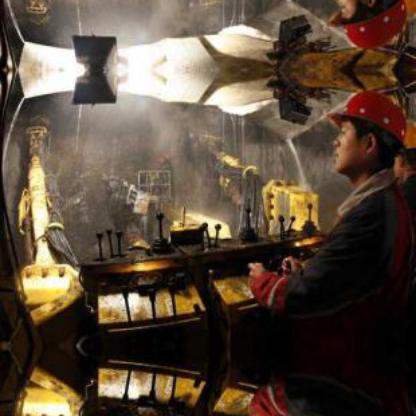

In [ ]:
from pathlib import Path

from IPython.display import Image, display

images_dir = Path("/content/datasets/raw/hard_hat_detection/images")
sample_images = sorted(list(images_dir.glob("*.png")))[:5]

for img in sample_images:
    print(img)
    display(Image(filename=str(img), width=500))

In [ ]:
import shutil
from pathlib import Path

images_dir = Path("/content/datasets/raw/hard_hat_detection/images")
sample_dir = Path("/content/datasets/sample_images")
sample_dir.mkdir(parents=True, exist_ok=True)

sample_images = sorted(list(images_dir.glob("*.png")))[:10]

for img in sample_images:
    shutil.copy(img, sample_dir / img.name)

print("Số ảnh mẫu:", len(list(sample_dir.glob("*.png"))))

Số ảnh mẫu: 10


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.predict(
    source="/content/datasets/sample_images",
    conf=0.25,
    save=True,
    project="/content/runs_compare",
    name="yolo11n_pretrained",
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/10 /content/datasets/sample_images/hard_hat_workers0.png: 640x640 11 persons, 8.3ms
image 2/10 /content/datasets/sample_images/hard_hat_workers1.png: 640x640 3 persons, 1 traffic light, 1 skis, 10.8ms
image 3/10 /content/datasets/sample_images/hard_hat_workers10.png: 640x640 5 persons, 8.1ms
image 4/10 /content/datasets/sample_images/hard_hat_workers100.png: 640x640 3 persons, 1 kite, 8.1ms
image 5/10 /content/datasets/sample_images/hard_hat_workers1000.png: 640x640 1 person, 1 chair, 8.1ms
image 6/10 /content/datasets/sample_images/hard_hat_workers1001.png: 640x640 2 persons, 1 suitcase, 2 frisbees, 13.0ms
image 7/10 /content/datasets/sample_images/hard_hat_workers1002.p

Số ảnh kết quả: 10


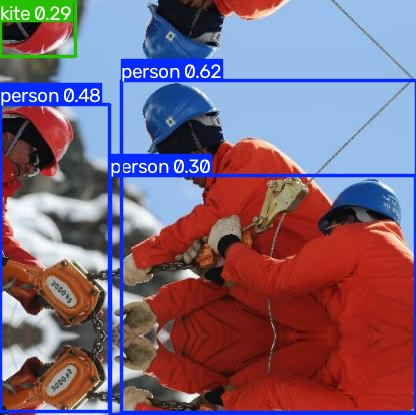

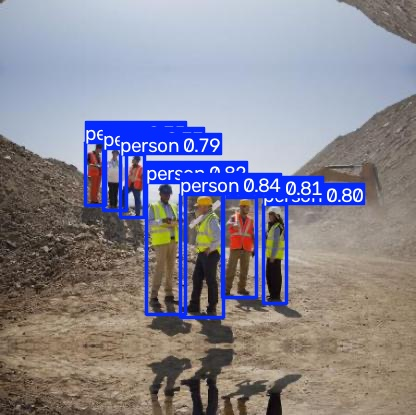

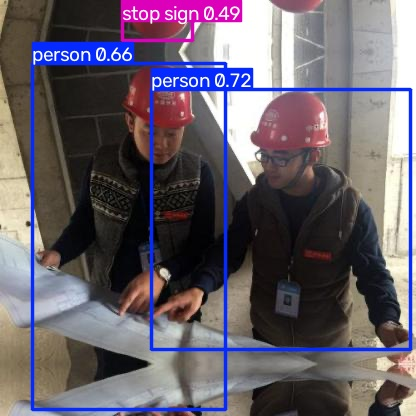

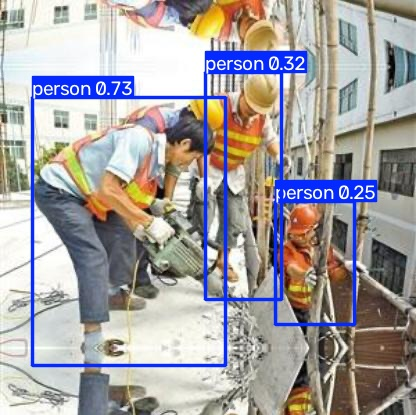

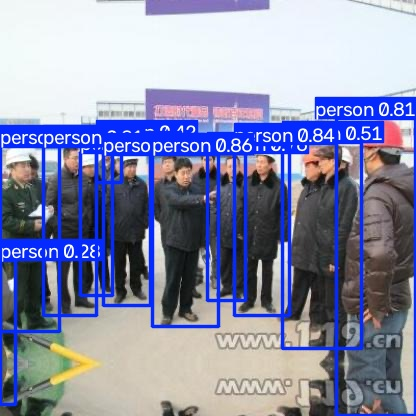

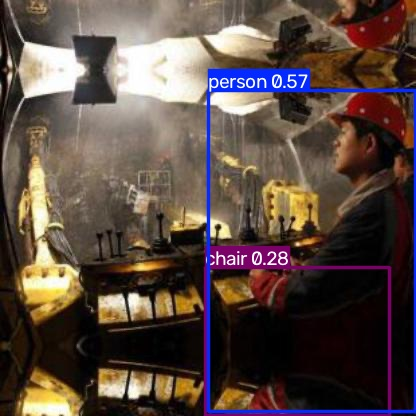

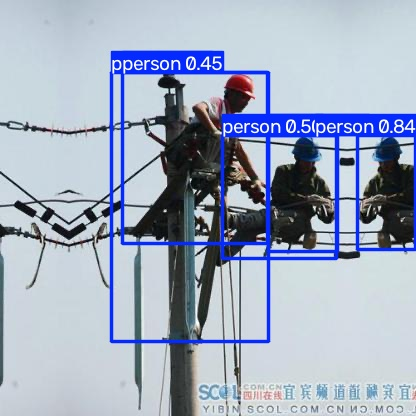

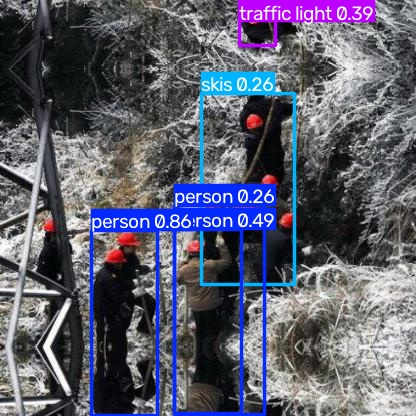

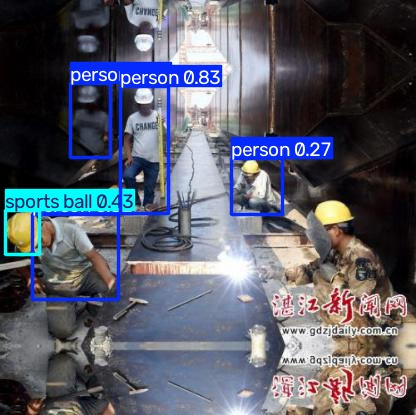

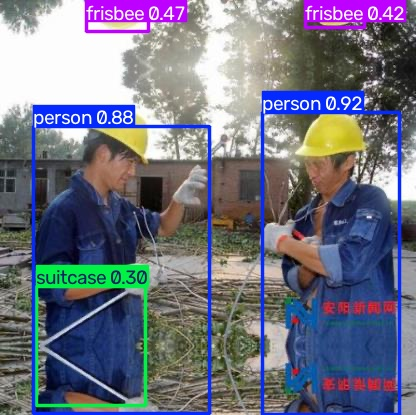

In [ ]:
from pathlib import Path

from IPython.display import Image, display

result_dir = Path("/content/runs_compare/yolo11n_pretrained")
result_images = list(result_dir.glob("*.png")) + list(result_dir.glob("*.jpg"))

print("Số ảnh kết quả:", len(result_images))

for img in result_images[:10]:
    display(Image(filename=str(img), width=500))

Convert XML to YOLO TXT

In [ ]:
import os
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

from PIL import Image
from sklearn.model_selection import train_test_split

raw_images_dir = Path("/content/datasets/raw/hard_hat_detection/images")
raw_annotations_dir = Path("/content/datasets/raw/hard_hat_detection/annotations")
output_dir = Path("/content/datasets/helmet_yolo")

if output_dir.exists():
    shutil.rmtree(output_dir)

class_map = {"helmet": 0, "head": 1}

for split in ["train", "val", "test"]:
    (output_dir / "images" / split).mkdir(parents=True, exist_ok=True)
    (output_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

image_files = sorted(
    list(raw_images_dir.glob("*.png"))
    + list(raw_images_dir.glob("*.jpg"))
    + list(raw_images_dir.glob("*.jpeg"))
)

train_files, temp_files = train_test_split(image_files, test_size=0.3, random_state=42)

val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

splits = {"train": train_files, "val": val_files, "test": test_files}


def convert_box(img_w, img_h, xmin, ymin, xmax, ymax):
    x_center = ((xmin + xmax) / 2) / img_w
    y_center = ((ymin + ymax) / 2) / img_h
    width = (xmax - xmin) / img_w
    height = (ymax - ymin) / img_h

    return x_center, y_center, width, height


converted_images = 0
converted_objects = 0

for split, files in splits.items():
    for image_path in files:
        annotation_path = raw_annotations_dir / f"{image_path.stem}.xml"

        if not annotation_path.exists():
            continue

        image = Image.open(image_path)
        img_w, img_h = image.size

        tree = ET.parse(annotation_path)
        root = tree.getroot()

        label_lines = []

        for obj in root.findall("object"):
            class_name = obj.find("name").text

            if class_name not in class_map:
                continue

            class_id = class_map[class_name]
            bndbox = obj.find("bndbox")

            xmin = float(bndbox.find("xmin").text)
            ymin = float(bndbox.find("ymin").text)
            xmax = float(bndbox.find("xmax").text)
            ymax = float(bndbox.find("ymax").text)

            x_center, y_center, width, height = convert_box(img_w, img_h, xmin, ymin, xmax, ymax)

            label_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

        if len(label_lines) == 0:
            continue

        shutil.copy(image_path, output_dir / "images" / split / image_path.name)

        label_path = output_dir / "labels" / split / f"{image_path.stem}.txt"

        with open(label_path, "w") as f:
            f.write("\n".join(label_lines))

        converted_images += 1
        converted_objects += len(label_lines)

print("Converted images:", converted_images)
print("Converted objects:", converted_objects)

Converted images: 5000
Converted objects: 24751


Crate data.yml


In [ ]:
data_yaml = """path: /content/datasets/helmet_yolo

train: images/train
val: images/val
test: images/test

names:
  0: with_helmet
  1: without_helmet
"""

with open("/content/datasets/helmet_yolo/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created")

data.yaml created


In [ ]:
from pathlib import Path

base = Path("/content/datasets/helmet_yolo")

for split in ["train", "val", "test"]:
    image_count = len(list((base / "images" / split).glob("*")))
    label_count = len(list((base / "labels" / split).glob("*.txt")))

    print(split, "images:", image_count, "labels:", label_count)

train images: 3500 labels: 3500
val images: 750 labels: 750
test images: 750 labels: 750


In [ ]:
from collections import Counter
from pathlib import Path

label_dir = Path("/content/datasets/helmet_yolo/labels")
counter = Counter()

for txt_file in label_dir.rglob("*.txt"):
    with open(txt_file) as f:
        for line in f:
            class_id = line.strip().split()[0]
            counter[class_id] += 1

print(counter)
print("0 = with_helmet")
print("1 = without_helmet")

Counter({'0': 18966, '1': 5785})
0 = with_helmet
1 = without_helmet


**Train YOLO**

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

model.train(
    data="/content/datasets/helmet_yolo/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    device=0,
    project="/content/runs_train",
    name="helmet_yolo11n",
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/helmet_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=helmet_yolo11n, nbs=64

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7df418134680>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs_train/helmet_yolo11n/weights/best.pt")

metrics = model.val(data="/content/datasets/helmet_yolo/data.yaml", split="test")

print(metrics)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2851.4±560.5 MB/s, size: 274.2 KB)
val: Scanning /content/datasets/helmet_yolo/labels/test... 750 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 750/750 1.2Kit/s 0.6s
val: New cache created: /content/datasets/helmet_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 3.7it/s 12.7s
                   all        750       3761      0.907      0.901       0.94      0.619
           with_helmet        681       2770      0.933      0.916      0.965      0.635
        without_helmet        144        991      0.881      0.886      0.914      0.603
Speed: 2.2ms preprocess, 4.4ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.me

Test fine-tune model


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs_train/helmet_yolo11n/weights/best.pt")

results = model.predict(
    source="/content/datasets/helmet_yolo/images/test",
    conf=0.25,
    save=True,
    project="/content/runs_predict",
    name="helmet_yolo11n_test",
)

Số ảnh kết quả: 750


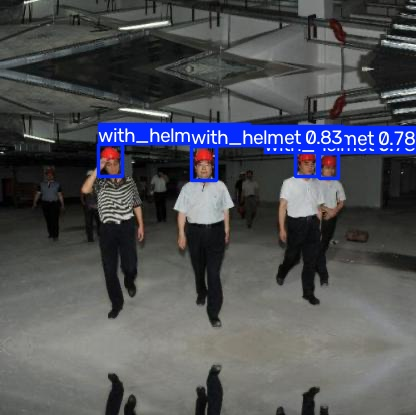

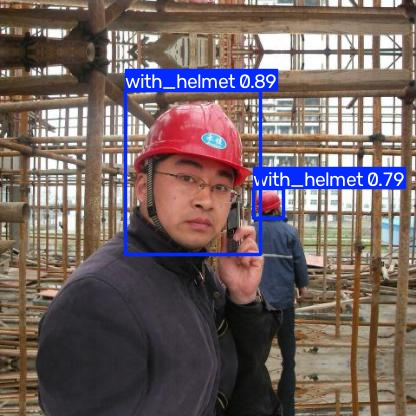

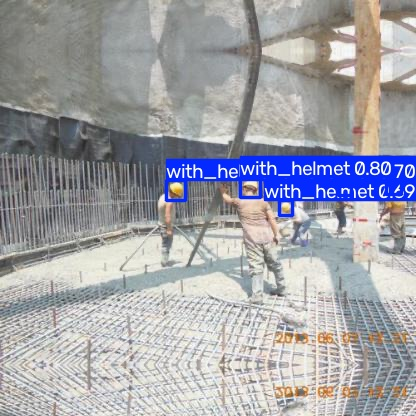

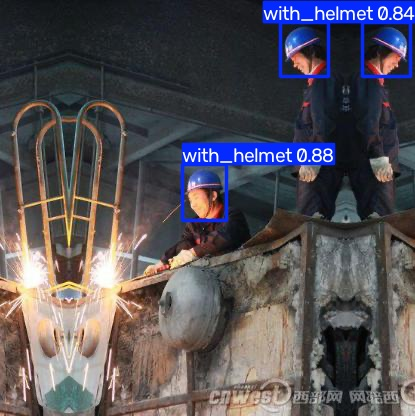

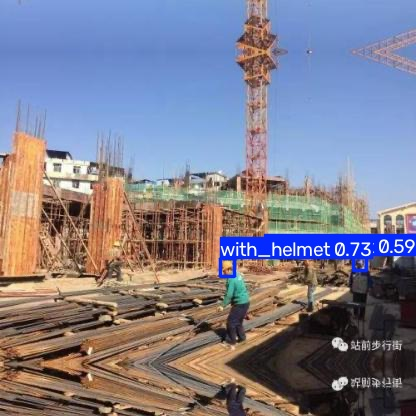

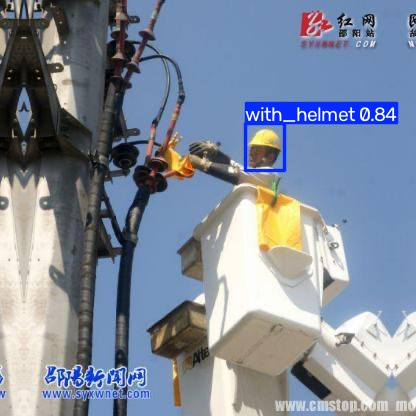

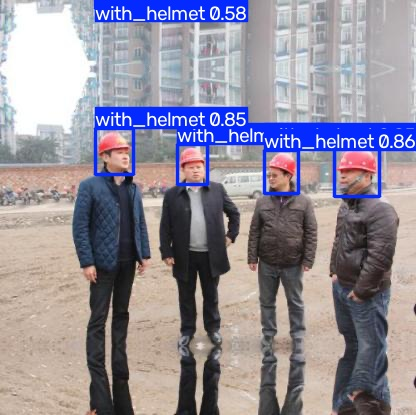

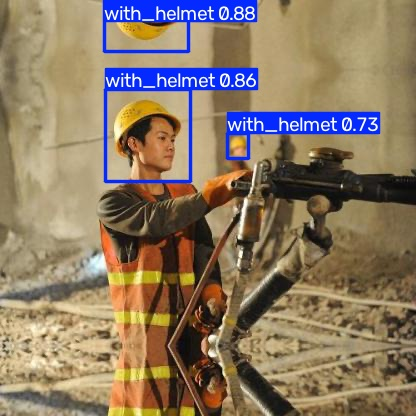

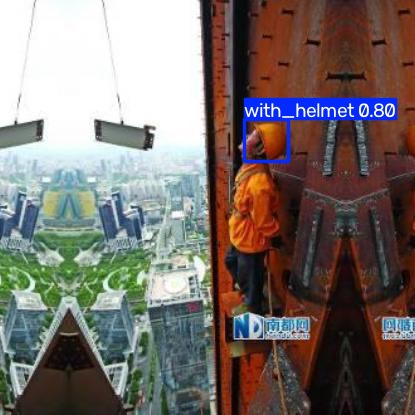

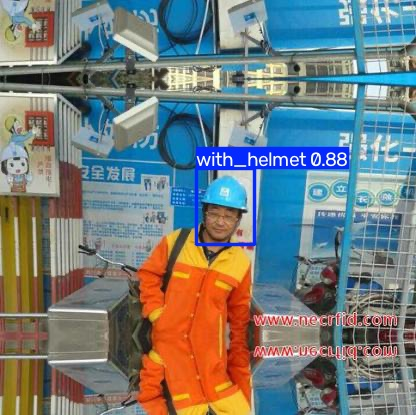

In [ ]:
from pathlib import Path

from IPython.display import Image, display

result_dir = Path("/content/runs_predict/helmet_yolo11n_test")
result_images = list(result_dir.glob("*.png")) + list(result_dir.glob("*.jpg"))

print("Số ảnh kết quả:", len(result_images))

for img in result_images[:10]:
    display(Image(filename=str(img), width=500))

## Multi-Dataset Evaluation (SHD_V2)

Evaluate the previously trained SHD_V2 model (from `First research`) alongside the Hard Hat Workers model trained above, to produce one combined metrics table (Precision, Recall, F1, mAP50, mAP50-95 on val and test).

This step does **not** retrain SHD_V2 — it only runs `model.val()` using the existing `best.pt` weights.

**Note on GDUT_HWD:** GDUT_HWD is excluded here. The images under `00_raw/gdut_hwd/valid/images` were found to actually be Hard Hat Workers images (filenames prefixed `hard_hat_workers...`, with Roboflow `.rf.<hash>` suffixes) mixed into the wrong folder, not real GDUT_HWD data — confirmed by drawing the labels on a sample image and reading the filename. Evaluating the GDUT_HWD-trained model against this mismatched data produced a meaningless mAP50 of ~0.12 (vs. ~0.93 in the original First research run). Until the correct GDUT_HWD raw data is located/re-collected in the Drive workspace, its baseline metrics table should keep using the original First research numbers, not a fresh eval from this notebook.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

# Adjust this if your NCKH folder lives at a different path in My Drive.
DRIVE_WORKSPACE = "/content/drive/MyDrive/NCKH/helmet_gdut_shd_workspace"
DRIVE_RAW = f"{DRIVE_WORKSPACE}/00_raw"

print("GDUT_HWD raw path:", f"{DRIVE_RAW}/gdut_hwd")
print("SHD_V2 raw path:", f"{DRIVE_RAW}/shd_v2")

In [ ]:
from pathlib import Path

# Pre-trained weights copied from local path
# in the project repo. Upload this .pt file into the same Drive workspace folder
# (e.g. helmet_gdut_shd_workspace/weights/) so the path below matches, or edit the path directly.
# NOTE: yolo11n_gdut_hwd_best.pt is intentionally not loaded here — see the markdown note above
# about the GDUT_HWD raw data mismatch found in 00_raw/gdut_hwd.
DRIVE_WEIGHTS = f"{DRIVE_WORKSPACE}/weights"

shd_v2_weights = f"{DRIVE_WEIGHTS}/yolo11n_shd_v2_best.pt"

assert Path(shd_v2_weights).exists(), f"Not found: {shd_v2_weights}"
print("Weights found OK")

In [ ]:
import pandas as pd
from ultralytics import YOLO

DATASETS = {
    "hard_hat_workers": {
        "data_yaml": "/content/datasets/helmet_yolo/data.yaml",
        "weights": "/content/runs_train/helmet_yolo11n/weights/best.pt",
    },
    "shd_v2": {
        "data_yaml": f"{DRIVE_RAW}/shd_v2/data.yaml",
        "weights": shd_v2_weights,
    },
}

rows = []

for dataset_name, cfg in DATASETS.items():
    model = YOLO(cfg["weights"])

    for split in ["val", "test"]:
        metrics = model.val(data=cfg["data_yaml"], split=split, verbose=False)

        precision = float(metrics.box.mp)
        recall = float(metrics.box.mr)
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        map50 = float(metrics.box.map50)
        map50_95 = float(metrics.box.map)

        rows.append(
            {
                "dataset": dataset_name,
                "split": split,
                "precision": round(precision, 4),
                "recall": round(recall, 4),
                "f1_score": round(f1, 4),
                "mAP50": round(map50, 4),
                "mAP50_95": round(map50_95, 4),
                "weights": cfg["weights"],
            }
        )

# GDUT_HWD row intentionally not computed here (see markdown note above).
# Keep using the First research numbers for GDUT_HWD in any combined report.
results_df = pd.DataFrame(rows)
results_df

In [ ]:
results_df.to_csv("/content/multi_dataset_metrics.csv", index=False)
print("Saved combined metrics table to /content/multi_dataset_metrics.csv")
results_df

In [ ]:
!mkdir -p /content/models/yolo11_helmet/weights
!cp /content/runs_train/helmet_yolo11n/weights/best.pt /content/models/yolo11_helmet/weights/best.pt
!ls -lh /content/models/yolo11_helmet/weights

total 5.3M
-rw-r--r-- 1 root root 5.3M Aug 18 02:06 best.pt


## Worker Zone Detection

Add a worker-zone module on top of the trained helmet model: detect people, assign each one to a configured zone (polygon-based), and report PPE (helmet) compliance per zone. Uses a pretrained YOLO11 COCO model for person detection since the dataset above has no person-level labels.

In [ ]:
import json
from pathlib import Path

zone_config_path = Path("/content/zone_config.json")

# Edit the polygons below to match the layout of the site/camera you are testing.
# Each zone is a polygon in pixel coordinates (x, y) over the source image.
zone_config = {
    "zones": [
        {
            "id": "zone_a",
            "name": "Scaffolding Area",
            "polygon": [[0, 0], [320, 0], [320, 640], [0, 640]],
        },
        {
            "id": "zone_b",
            "name": "Crane Operation Area",
            "polygon": [[320, 0], [640, 0], [640, 640], [320, 640]],
        },
    ]
}

with open(zone_config_path, "w") as f:
    json.dump(zone_config, f, indent=2)

print("Zone config written to:", zone_config_path)

Zone config written to: /content/zone_config.json


In [ ]:
%%writefile /content/models/yolo11_helmet/worker_zone_detector.py
import json

import cv2
from ultralytics import YOLO

PERSON_CLASS_ID = 0  # COCO class id for "person"


def load_zone_config(path):
    with open(path, "r") as f:
        config = json.load(f)

    zones = []
    for zone in config["zones"]:
        polygon = [(float(x), float(y)) for x, y in zone["polygon"]]
        zones.append({"id": zone["id"], "name": zone.get("name", zone["id"]), "polygon": polygon})
    return zones


def point_in_polygon(point, polygon):
    x, y = point
    inside = False
    n = len(polygon)
    for i in range(n):
        x1, y1 = polygon[i]
        x2, y2 = polygon[(i + 1) % n]
        if ((y1 > y) != (y2 > y)) and (x < (x2 - x1) * (y - y1) / (y2 - y1) + x1):
            inside = not inside
    return inside


def assign_zone(box_xyxy, zones):
    x1, y1, x2, y2 = box_xyxy
    foot_point = ((x1 + x2) / 2.0, y2)
    for zone in zones:
        if point_in_polygon(foot_point, zone["polygon"]):
            return zone["id"], zone["name"]
    return None, None


def box_center(box_xyxy):
    x1, y1, x2, y2 = box_xyxy
    return (x1 + x2) / 2.0, (y1 + y2) / 2.0


def match_ppe_to_person(person_box, ppe_detections):
    x1, y1, x2, y2 = person_box
    best = None
    best_dist = None
    for det in ppe_detections:
        cx, cy = box_center(det["box"])
        if x1 <= cx <= x2 and y1 <= cy <= y2:
            dist = cy - y1
            if best_dist is None or dist < best_dist:
                best = det
                best_dist = dist
    return best


def extract_detections(result, class_filter=None):
    detections = []
    names = result.names
    for box in result.boxes:
        cls_id = int(box.cls[0])
        if class_filter is not None and cls_id not in class_filter:
            continue
        xyxy = tuple(box.xyxy[0].tolist())
        detections.append({
            "class_id": cls_id,
            "class_name": names.get(cls_id, str(cls_id)),
            "conf": float(box.conf[0]),
            "box": xyxy,
        })
    return detections


class WorkerZoneDetector:
    def __init__(self, zone_config_path, person_weights="yolo11n.pt", ppe_weights=None, conf=0.25):
        self.zones = load_zone_config(zone_config_path)
        self.person_model = YOLO(person_weights)
        self.ppe_model = YOLO(ppe_weights) if ppe_weights else None
        self.conf = conf

    def process_frame(self, image):
        person_result = self.person_model.predict(source=image, conf=self.conf, verbose=False)[0]
        person_detections = extract_detections(person_result, class_filter={PERSON_CLASS_ID})

        ppe_detections = []
        if self.ppe_model is not None:
            ppe_result = self.ppe_model.predict(source=image, conf=self.conf, verbose=False)[0]
            ppe_detections = extract_detections(ppe_result)

        workers = []
        for person in person_detections:
            zone_id, zone_name = assign_zone(person["box"], self.zones)
            ppe_match = match_ppe_to_person(person["box"], ppe_detections) if ppe_detections else None
            workers.append({
                "box": person["box"],
                "conf": person["conf"],
                "zone_id": zone_id,
                "zone_name": zone_name,
                "ppe_status": ppe_match["class_name"] if ppe_match else "unknown",
            })

        return workers

    def summarize_by_zone(self, workers):
        summary = {
            zone["id"]: {"name": zone["name"], "total": 0, "with_helmet": 0, "without_helmet": 0, "unknown": 0}
            for zone in self.zones
        }
        summary["unassigned"] = {"name": "Unassigned", "total": 0, "with_helmet": 0, "without_helmet": 0, "unknown": 0}

        for worker in workers:
            key = worker["zone_id"] if worker["zone_id"] else "unassigned"
            summary[key]["total"] += 1
            status = worker["ppe_status"]
            if status in ("with_helmet", "without_helmet"):
                summary[key][status] += 1
            else:
                summary[key]["unknown"] += 1

        return summary

    def draw_overlay(self, image, workers):
        image = image.copy()
        for zone in self.zones:
            pts = [(int(x), int(y)) for x, y in zone["polygon"]]
            for i in range(len(pts)):
                cv2.line(image, pts[i], pts[(i + 1) % len(pts)], (255, 200, 0), 2)
            cv2.putText(image, zone["name"], pts[0], cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 200, 0), 2)

        for worker in workers:
            x1, y1, x2, y2 = [int(v) for v in worker["box"]]
            if worker["ppe_status"] == "with_helmet":
                color = (0, 255, 0)
            elif worker["ppe_status"] == "without_helmet":
                color = (0, 0, 255)
            else:
                color = (0, 165, 255)
            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
            label = f"{worker['zone_name'] or 'no-zone'} | {worker['ppe_status']}"
            cv2.putText(image, label, (x1, max(0, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        return image


Writing /content/models/yolo11_helmet/worker_zone_detector.py


In [ ]:
import sys
from pathlib import Path

import cv2

sys.path.append("/content/models/yolo11_helmet")
from worker_zone_detector import WorkerZoneDetector

detector = WorkerZoneDetector(
    zone_config_path="/content/zone_config.json",
    person_weights="yolo11n.pt",
    ppe_weights="/content/models/yolo11_helmet/weights/best.pt",
    conf=0.25,
)

test_images_dir = Path("/content/datasets/helmet_yolo/images/test")
output_dir = Path("/content/runs_zone")
output_dir.mkdir(parents=True, exist_ok=True)

sample_images = (
    sorted(test_images_dir.glob("*.png"))[:10] + sorted(test_images_dir.glob("*.jpg"))[:10]
)

zone_report = {}

for image_path in sample_images:
    image = cv2.imread(str(image_path))
    if image is None:
        continue

    workers = detector.process_frame(image)
    summary = detector.summarize_by_zone(workers)
    zone_report[image_path.name] = summary

    annotated = detector.draw_overlay(image, workers)
    cv2.imwrite(str(output_dir / image_path.name), annotated)

    print(image_path.name, "-", len(workers), "worker(s) detected")
    for _zone_id, stats in summary.items():
        if stats["total"] > 0:
            print("   ", stats["name"], ":", stats)

print("Annotated images saved to:", output_dir)

hard_hat_workers1004.png - 4 worker(s) detected
    Scaffolding Area : {'name': 'Scaffolding Area', 'total': 4, 'with_helmet': 3, 'without_helmet': 0, 'unknown': 1}
hard_hat_workers1008.png - 2 worker(s) detected
    Scaffolding Area : {'name': 'Scaffolding Area', 'total': 2, 'with_helmet': 1, 'without_helmet': 0, 'unknown': 1}
hard_hat_workers101.png - 6 worker(s) detected
    Scaffolding Area : {'name': 'Scaffolding Area', 'total': 5, 'with_helmet': 0, 'without_helmet': 5, 'unknown': 0}
    Crane Operation Area : {'name': 'Crane Operation Area', 'total': 1, 'with_helmet': 0, 'without_helmet': 1, 'unknown': 0}
hard_hat_workers1012.png - 3 worker(s) detected
    Scaffolding Area : {'name': 'Scaffolding Area', 'total': 3, 'with_helmet': 3, 'without_helmet': 0, 'unknown': 0}
hard_hat_workers1023.png - 8 worker(s) detected
    Scaffolding Area : {'name': 'Scaffolding Area', 'total': 6, 'with_helmet': 4, 'without_helmet': 0, 'unknown': 2}
    Crane Operation Area : {'name': 'Crane Operatio

So anh ket qua: 10


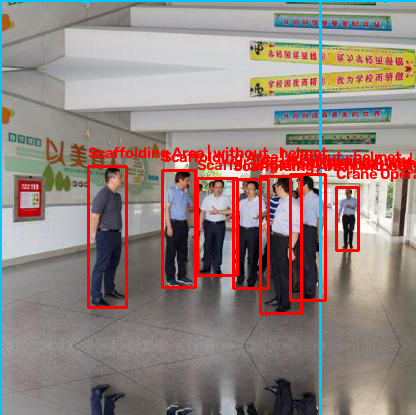

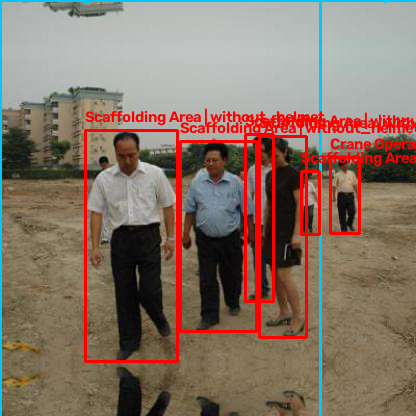

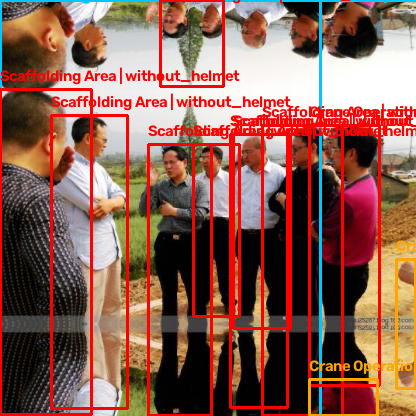

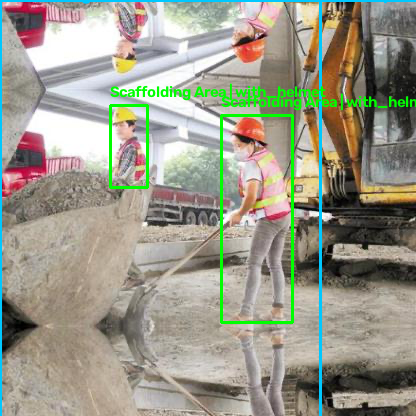

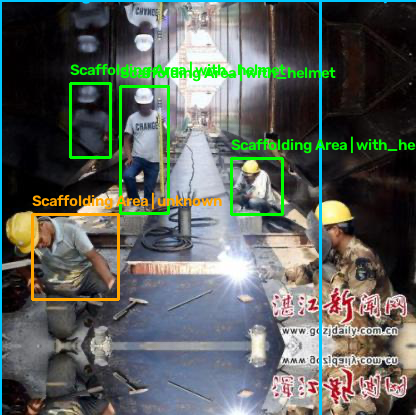

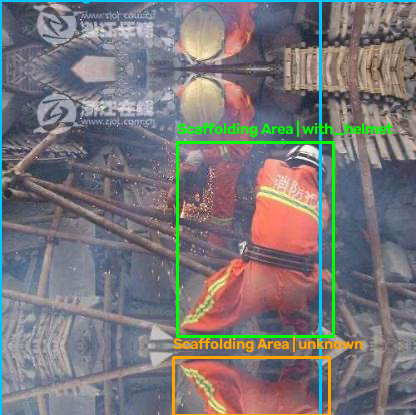

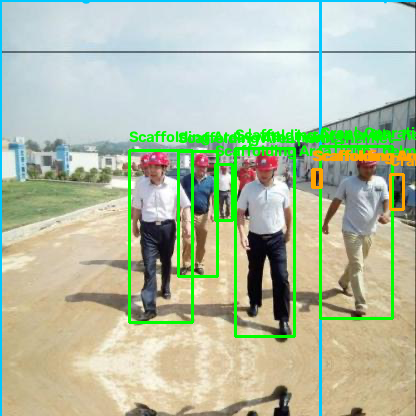

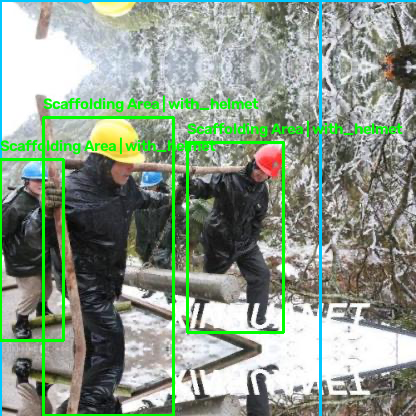

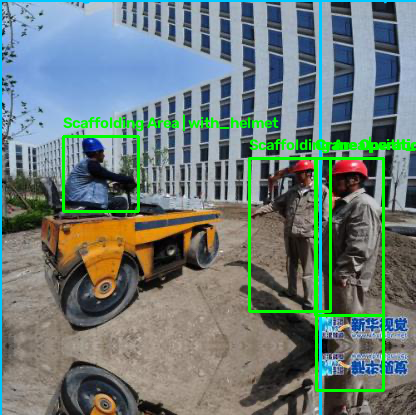

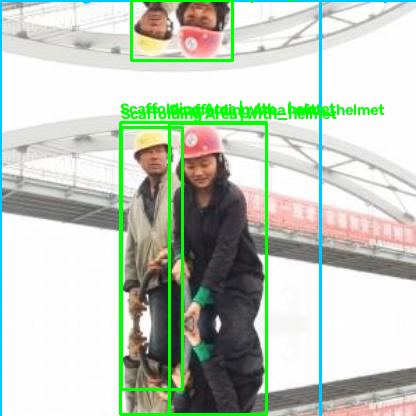

In [ ]:
from pathlib import Path

from IPython.display import Image, display

result_dir = Path("/content/runs_zone")
result_images = list(result_dir.glob("*.png")) + list(result_dir.glob("*.jpg"))

print("So anh ket qua:", len(result_images))

for img in result_images[:10]:
    display(Image(filename=str(img), width=500))

Create Wrapper

In [ ]:
%%writefile /content/models/yolo11_helmet/yolo_detector.py
from ultralytics import YOLO


class YOLOHelmetDetector:
    def __init__(self, model_path="weights/best.pt", conf=0.25, device=None):
        self.model = YOLO(model_path)
        self.conf = conf
        self.device = device

    def predict(self, source, save=False):
        results = self.model.predict(
            source=source,
            conf=self.conf,
            device=self.device,
            save=save
        )

        return self.format_results(results)

    def format_results(self, results):
        detections = []

        for result in results:
            if result.boxes is None:
                continue

            image_path = result.path

            for box in result.boxes:
                class_id = int(box.cls[0])
                class_name = self.model.names[class_id]
                confidence = float(box.conf[0])
                bbox = box.xyxy[0].tolist()

                detections.append({
                    "image_path": image_path,
                    "class_id": class_id,
                    "class_name": class_name,
                    "confidence": confidence,
                    "bbox": bbox
                })

        return detections

Writing /content/models/yolo11_helmet/yolo_detector.py


Create test file

In [ ]:
%%writefile /content/models/yolo11_helmet/test_predict.py
from yolo_detector import YOLOHelmetDetector


detector = YOLOHelmetDetector(
    model_path="weights/best.pt",
    conf=0.25
)

detections = detector.predict(
    source="/content/datasets/helmet_yolo/images/test",
    save=True
)

print("Total detections:", len(detections))
print(detections[:10])

Writing /content/models/yolo11_helmet/test_predict.py


In [ ]:
%%writefile /content/models/yolo11_helmet/requirements.txt
ultralytics
opencv-python
numpy
torch
torchvision
pandas
matplotlib
scikit-learn
pillow

Writing /content/models/yolo11_helmet/requirements.txt


In [ ]:
%cd /content/models/yolo11_helmet
!python test_predict.py

/content/models/yolo11_helmet

image 1/750 /content/datasets/helmet_yolo/images/test/hard_hat_workers1004.png: 640x640 7 with_helmets, 8.1ms
image 2/750 /content/datasets/helmet_yolo/images/test/hard_hat_workers1008.png: 640x640 3 with_helmets, 8.2ms
image 3/750 /content/datasets/helmet_yolo/images/test/hard_hat_workers101.png: 640x640 7 without_helmets, 12.5ms
image 4/750 /content/datasets/helmet_yolo/images/test/hard_hat_workers1012.png: 640x640 5 with_helmets, 15.6ms
image 5/750 /content/datasets/helmet_yolo/images/test/hard_hat_workers1023.png: 640x640 5 with_helmets, 7.8ms
image 6/750 /content/datasets/helmet_yolo/images/test/hard_hat_workers1024.png: 640x640 8 without_helmets, 7.8ms
image 7/750 /content/datasets/helmet_yolo/images/test/hard_hat_workers1036.png: 640x640 3 with_helmets, 7.8ms
image 8/750 /content/datasets/helmet_yolo/images/test/hard_hat_workers1038.png: 640x640 15 without_helmets, 7.8ms
image 9/750 /content/datasets/helmet_yolo/images/test/hard_hat_workers1043.png

In [ ]:
%cd /content
!zip -r yolo11_helmet.zip models/yolo11_helmet

/content
  adding: models/yolo11_helmet/ (stored 0%)
  adding: models/yolo11_helmet/yolo_detector.py (deflated 64%)
  adding: models/yolo11_helmet/weights/ (stored 0%)
  adding: models/yolo11_helmet/weights/best.pt (deflated 10%)
  adding: models/yolo11_helmet/requirements.txt (deflated 17%)
  adding: models/yolo11_helmet/runs/ (stored 0%)
  adding: models/yolo11_helmet/runs/detect/ (stored 0%)
  adding: models/yolo11_helmet/runs/detect/predict/ (stored 0%)
  adding: models/yolo11_helmet/runs/detect/predict/hard_hat_workers697.jpg (deflated 2%)
  adding: models/yolo11_helmet/runs/detect/predict/hard_hat_workers1275.jpg (deflated 2%)
  adding: models/yolo11_helmet/runs/detect/predict/hard_hat_workers4151.jpg (deflated 3%)
  adding: models/yolo11_helmet/runs/detect/predict/hard_hat_workers3018.jpg (deflated 2%)
  adding: models/yolo11_helmet/runs/detect/predict/hard_hat_workers3203.jpg (deflated 5%)
  adding: models/yolo11_helmet/runs/detect/predict/hard_hat_workers3694.jpg (deflated 2%)

In [ ]:
from google.colab import files

files.download("/content/yolo11_helmet.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>